# Wimbledon 2026 — Analytical Deep Dive

This notebook answers four analytical questions that complement the prediction model:

1. **SHAP feature analysis** — which features drive predictions, and by how much?
2. **Where does the model fail?** — characterise systematic errors
3. **ELO vs ranking** — does ELO beat raw ATP rankings as a predictor?
4. **Upset rate by round** — does the model's calibration match historical Wimbledon upset patterns?

Run from the repo root: `jupyter notebook notebooks/analysis.ipynb`

In [1]:
import sys, os
# Move CWD to repo root so relative paths and SQL file references work
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')   # make tennis_predictor importable

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from xgboost import XGBClassifier

from tennis_predictor.duckdb_data import load_atp_data, load_atp_rankings, sql
from tennis_predictor.elo import EloEngine
from tennis_predictor.stats import build_stats
from tennis_predictor.features import FEATURE_NAMES, build_features
from tennis_predictor.config import TRAIN_END_YEAR, CALIB_YEAR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Imports OK — CWD:', os.getcwd())

Imports OK — CWD: /Users/limuzi/Wimbledon-Prediction


## Setup: load data and train model
*(~2 minutes — ELO computation over 64k+ matches)*

In [2]:
# Load data via DuckDB — single SQL scan across all yearly CSV files
df_all   = load_atp_data(start_year=2010, end_year=2026)
df_train = df_all[df_all['tourney_date'].dt.year <= TRAIN_END_YEAR]
df_calib = df_all[df_all['tourney_date'].dt.year == CALIB_YEAR]
df_val   = df_all[(df_all['tourney_date'].dt.year >= 2024) &
                  (df_all['tourney_date'].dt.year <= 2025)]
rankings = load_atp_rankings()

print(f'Train: {len(df_train):,}  Calib: {len(df_calib):,}  Val: {len(df_val):,}')
print(f'Surfaces in training: {df_train["surface"].value_counts().to_dict()}')

Train: 32,060  Calib: 2,675  Val: 5,218
Surfaces in training: {'Hard': 18549, 'Clay': 9855, 'Grass': 3656}


In [3]:
print('Computing ELO ratings and building features...')
engine = EloEngine()
engine.process_dataframe(df_train)
snaps_tr = engine.get_snapshots_df()
stats_tr = build_stats(df_train)
X_tr, y_tr, w_tr = build_features(df_train, snaps_tr, rankings=rankings, **stats_tr)
print(f'Training examples: {len(X_tr):,}  (grass upweighted 3×)')

xgb = XGBClassifier(
    n_estimators=600, max_depth=4, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0, eval_metric='logloss',
    use_label_encoder=False, random_state=42, verbosity=0,
)
xgb.fit(X_tr, y_tr, sample_weight=w_tr)
print('XGBoost trained')

engine.process_dataframe(df_calib)
snaps_cal = engine.get_snapshots_df()
stats_cal = build_stats(pd.concat([df_train, df_calib]))
X_cal, y_cal, _ = build_features(df_calib, snaps_cal, rankings=rankings, **stats_cal)
gi = FEATURE_NAMES.index('is_grass')
gm = X_cal[:, gi] == 1.0
calibrated = CalibratedClassifierCV(xgb, cv='prefit', method='isotonic')
calibrated.fit(X_cal[gm], y_cal[gm])
print('Isotonic calibration fitted')

engine.process_dataframe(df_val)
snaps_val = engine.get_snapshots_df()
stats_val = build_stats(pd.concat([df_train, df_calib, df_val]))
X_val, y_val, _ = build_features(df_val, snaps_val, rankings=rankings, **stats_val)
gm_v = X_val[:, gi] == 1.0
X_g, y_g = X_val[gm_v], y_val[gm_v]
print(f'Validation grass samples: {len(X_g):,}')

prob_raw = xgb.predict_proba(X_g)[:, 1]
prob_cal = calibrated.predict_proba(X_g)[:, 1]

Computing ELO ratings and building features...


Training examples: 64,120  (grass upweighted 3×)


XGBoost trained


Isotonic calibration fitted


Validation grass samples: 1,198


---
## Question 1 — SHAP feature analysis

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score **per prediction**, not just a global average. This tells us which features drive the model's confidence on specific matches.

Computing SHAP values...


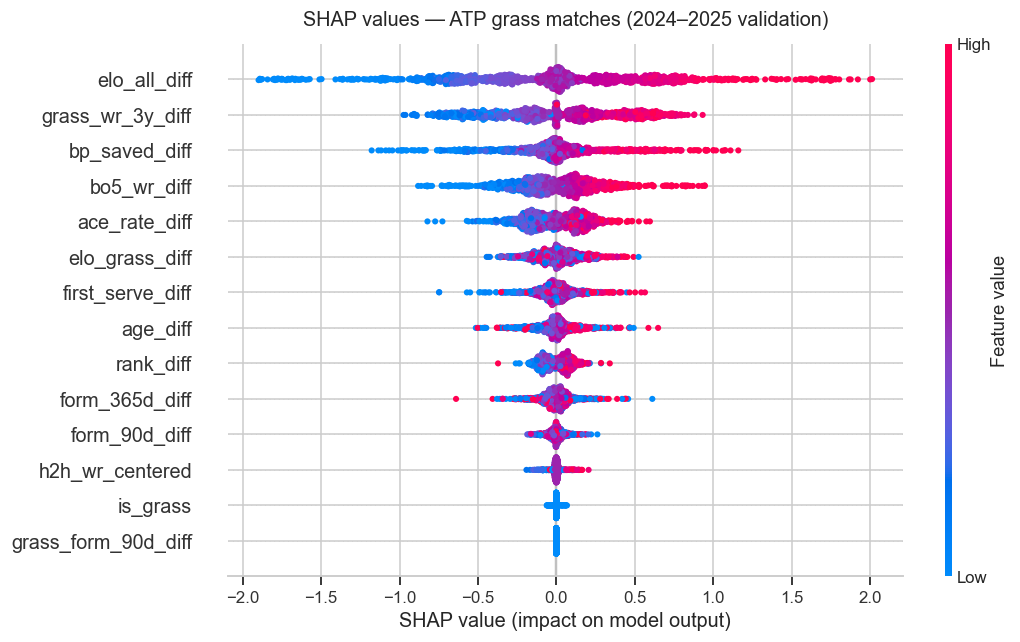

In [4]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_g)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_g, feature_names=FEATURE_NAMES,
    show=False, max_display=14, plot_size=None,
)
plt.title('SHAP values — ATP grass matches (2024–2025 validation)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

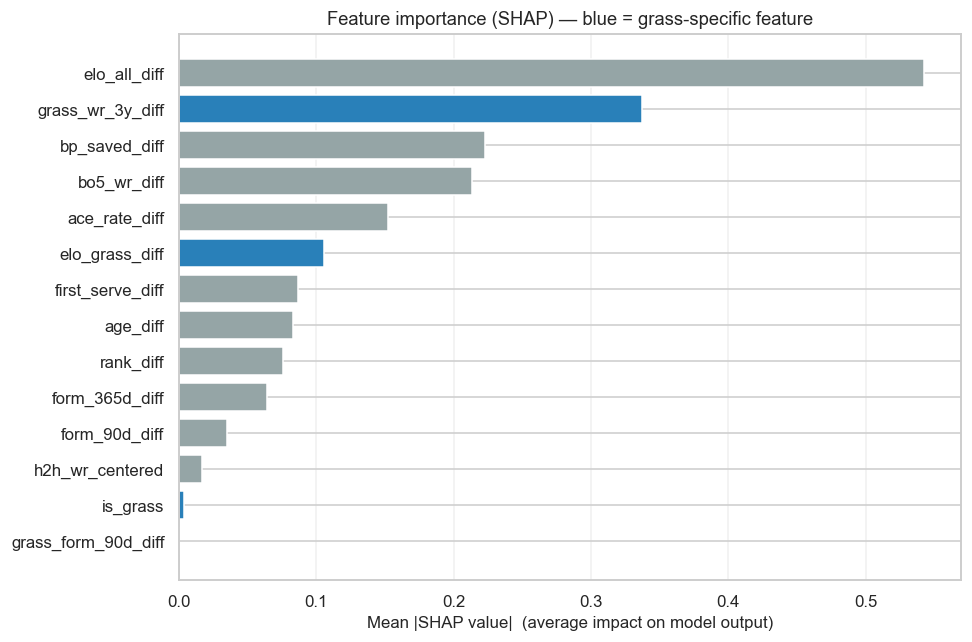

Grass-specific features: 46.9% of total SHAP mass
General features:        53.1% of total SHAP mass

Top features by mean |SHAP|:
  elo_all_diff              0.5426
  grass_wr_3y_diff          0.3374 ← grass-specific
  bp_saved_diff             0.2231 ← grass-specific
  bo5_wr_diff               0.2132
  ace_rate_diff             0.1522 ← grass-specific
  elo_grass_diff            0.1055 ← grass-specific
  first_serve_diff          0.0864 ← grass-specific
  age_diff                  0.0831
  rank_diff                 0.0756
  form_365d_diff            0.0640
  form_90d_diff             0.0346
  h2h_wr_centered           0.0167
  is_grass                  0.0040 ← grass-specific
  grass_form_90d_diff       0.0000 ← grass-specific


In [5]:
mean_shap = np.abs(shap_values).mean(axis=0)
order     = np.argsort(mean_shap)
names_ord = [FEATURE_NAMES[i] for i in order]
vals_ord  = mean_shap[order]
colors    = ['#2980b9' if 'grass' in n or n == 'is_grass' else '#95a5a6' for n in names_ord]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(names_ord, vals_ord, color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|  (average impact on model output)', fontsize=11)
ax.set_title('Feature importance (SHAP) — blue = grass-specific feature', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Grass vs non-grass SHAP share
grass_feats   = ['elo_grass_diff','grass_wr_3y_diff','grass_form_90d_diff','ace_rate_diff','first_serve_diff','bp_saved_diff','is_grass']
general_feats = [f for f in FEATURE_NAMES if f not in grass_feats]
grass_share   = sum(mean_shap[FEATURE_NAMES.index(f)] for f in grass_feats) / mean_shap.sum()

print(f'Grass-specific features: {grass_share*100:.1f}% of total SHAP mass')
print(f'General features:        {(1-grass_share)*100:.1f}% of total SHAP mass')
print(f'\nTop features by mean |SHAP|:')
for n, v in zip(reversed(names_ord), reversed(vals_ord)):
    tag = ' ← grass-specific' if n in grass_feats else ''
    print(f'  {n:<24}  {v:.4f}{tag}')

---
## Question 2 — Where does the model fail?

We examine matches where the model predicted ≥ 70% probability for one player but the other player won. Understanding failure modes is as analytically valuable as knowing where the model succeeds.

In [6]:
model_pred      = (prob_cal >= 0.5).astype(int)
errors          = model_pred != y_g
high_conf_wrong = (prob_cal >= 0.70) & errors

print(f'Total grass matches:          {len(y_g):,}')
print(f'Total errors:                 {errors.sum():,}  ({errors.mean()*100:.1f}%)')
print(f'High-conf errors (≥70%):      {high_conf_wrong.sum():,}  ({high_conf_wrong.mean()*100:.1f}%)')

rd_idx = FEATURE_NAMES.index('rank_diff')
# Are high-conf errors genuine upsets (ranking also agreed the wrong player should win)?
rank_agreed_wrong = X_g[high_conf_wrong, rd_idx] > 0
print(f'\nOf the {high_conf_wrong.sum()} high-conf errors:')
print(f'  {rank_agreed_wrong.sum()} ({rank_agreed_wrong.mean()*100:.0f}%) were genuine upsets — ranking also backed the loser')
print(f'  Avg rank gap in those upsets: {X_g[high_conf_wrong, rd_idx][rank_agreed_wrong].mean():.0f} positions')

Total grass matches:          1,198
Total errors:                 352  (29.4%)
High-conf errors (≥70%):      66  (5.5%)

Of the 66 high-conf errors:
  47 (71%) were genuine upsets — ranking also backed the loser
  Avg rank gap in those upsets: 133 positions


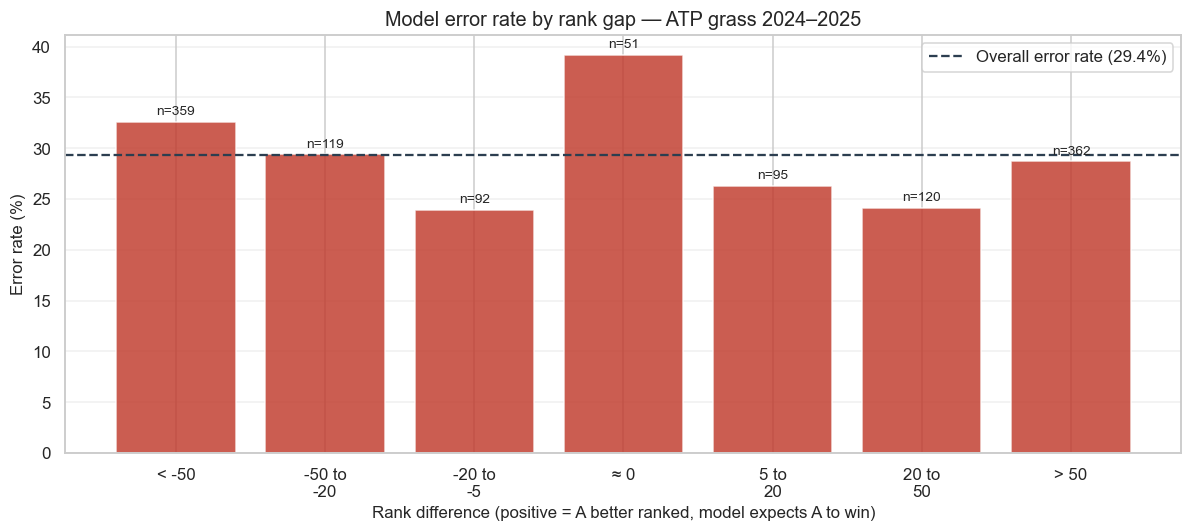

Insight: error rate spikes when rank_diff > 50 (large underdog wins) —
exactly the high-rank-gap upsets where grass variance overwhelms all signals.


In [7]:
# Error rate by rank gap bucket
rank_diff = X_g[:, rd_idx]
bins   = [-300, -50, -20, -5, 5, 20, 50, 300]
labels = ['< -50', '-50 to\n-20', '-20 to\n-5', '≈ 0', '5 to\n20', '20 to\n50', '> 50']
bin_idx = np.clip(np.digitize(rank_diff, bins) - 1, 0, len(labels) - 1)

error_rates, counts = [], []
for i in range(len(labels)):
    mask = bin_idx == i
    error_rates.append(errors[mask].mean() * 100 if mask.sum() > 0 else 0)
    counts.append(mask.sum())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, error_rates, color='#c0392b', alpha=0.82, edgecolor='white')
ax.axhline(errors.mean() * 100, color='#2c3e50', linestyle='--', lw=1.5,
           label=f'Overall error rate ({errors.mean()*100:.1f}%)')
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'n={n:,}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Rank difference (positive = A better ranked, model expects A to win)', fontsize=11)
ax.set_ylabel('Error rate (%)', fontsize=11)
ax.set_title('Model error rate by rank gap — ATP grass 2024–2025', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Insight: error rate spikes when rank_diff > 50 (large underdog wins) —')
print('exactly the high-rank-gap upsets where grass variance overwhelms all signals.')

---
## Question 3 — ELO vs ranking: which predicts better?

Three predictors compared on the 2024–2025 grass holdout:
- **Ranking baseline** — does the better-ranked (lower number) player win?
- **ELO baseline** — does the player with the higher overall ELO win?
- **Full XGBoost** — all 14 features + isotonic calibration

In [8]:
rd_idx  = FEATURE_NAMES.index('rank_diff')
elo_idx = FEATURE_NAMES.index('elo_all_diff')

rank_pred  = (X_g[:, rd_idx]  > 0).astype(int)
elo_pred   = (X_g[:, elo_idx] > 0).astype(int)

rank_prob = 1 / (1 + np.exp(-X_g[:, rd_idx]  / 30))
elo_prob  = 1 / (1 + np.exp(-X_g[:, elo_idx] / 80))

rank_acc  = accuracy_score(y_g, rank_pred)
elo_acc   = accuracy_score(y_g, elo_pred)
model_acc = accuracy_score(y_g, model_pred)
rank_auc  = roc_auc_score(y_g, rank_prob)
elo_auc   = roc_auc_score(y_g, elo_prob)
model_auc = roc_auc_score(y_g, prob_cal)

print(f'{"Predictor":<25} {"Accuracy":>10} {"AUC-ROC":>10}')
print('-' * 47)
print(f'{"ATP Ranking":<25} {rank_acc:>10.4f} {rank_auc:>10.4f}')
print(f'{"Overall ELO":<25} {elo_acc:>10.4f} {elo_auc:>10.4f}')
print(f'{"XGBoost (calibrated)":<25} {model_acc:>10.4f} {model_auc:>10.4f}')
print(f'\nELO lift over ranking:  +{(elo_acc-rank_acc)*100:.1f}pp accuracy, +{(elo_auc-rank_auc)*100:.1f}pp AUC')
print(f'Model lift over ranking: +{(model_acc-rank_acc)*100:.1f}pp accuracy, +{(model_auc-rank_auc)*100:.1f}pp AUC')

Predictor                   Accuracy    AUC-ROC
-----------------------------------------------
ATP Ranking                   0.6561     0.6839
Overall ELO                   0.6861     0.7337
XGBoost (calibrated)          0.7062     0.7680

ELO lift over ranking:  +3.0pp accuracy, +5.0pp AUC
Model lift over ranking: +5.0pp accuracy, +8.4pp AUC


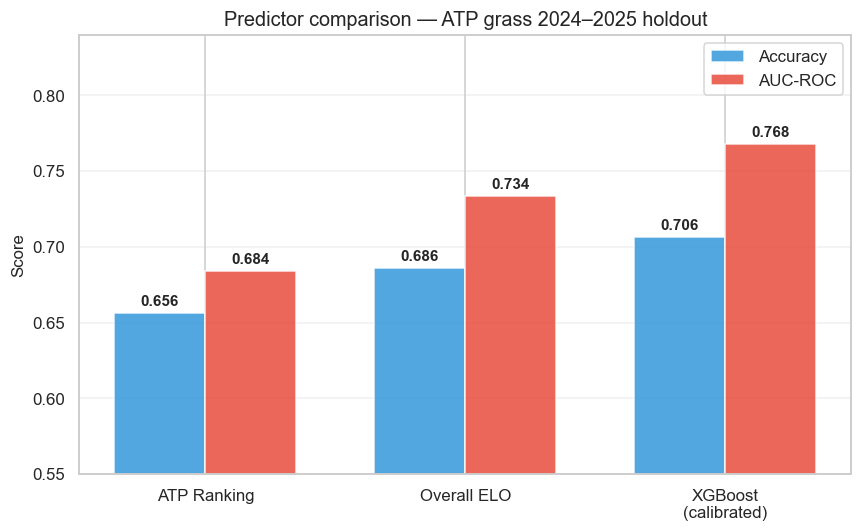

In [9]:
x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, [rank_acc, elo_acc, model_acc], w, label='Accuracy', color='#3498db', alpha=0.85)
b2 = ax.bar(x + w/2, [rank_auc, elo_auc, model_auc], w, label='AUC-ROC',  color='#e74c3c', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['ATP Ranking', 'Overall ELO', 'XGBoost\n(calibrated)'], fontsize=11)
ax.set_ylim(0.55, 0.84)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Predictor comparison — ATP grass 2024–2025 holdout', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Question 4 — Upset rate by round

Does the model's calibration match the historical Wimbledon upset rate across rounds?  
We run the SQL query directly with DuckDB.

In [10]:
upset_df = sql(open('queries/03_upset_rate_by_round.sql').read())
# Filter to main draw only (R128 through F)
main_draw = upset_df[upset_df['round_num'] <= 7].sort_values('round_num')
print(main_draw[['round', 'total_matches', 'upsets', 'upset_rate_pct']].to_string(index=False))

round  total_matches  upsets  upset_rate_pct
 R128            930   299.0            32.2
  R64            458   125.0            27.3
  R32            233    65.0            27.9
  R16            114    23.0            20.2
   QF             58    11.0            19.0
   SF             29     5.0            17.2
    F             15     4.0            26.7


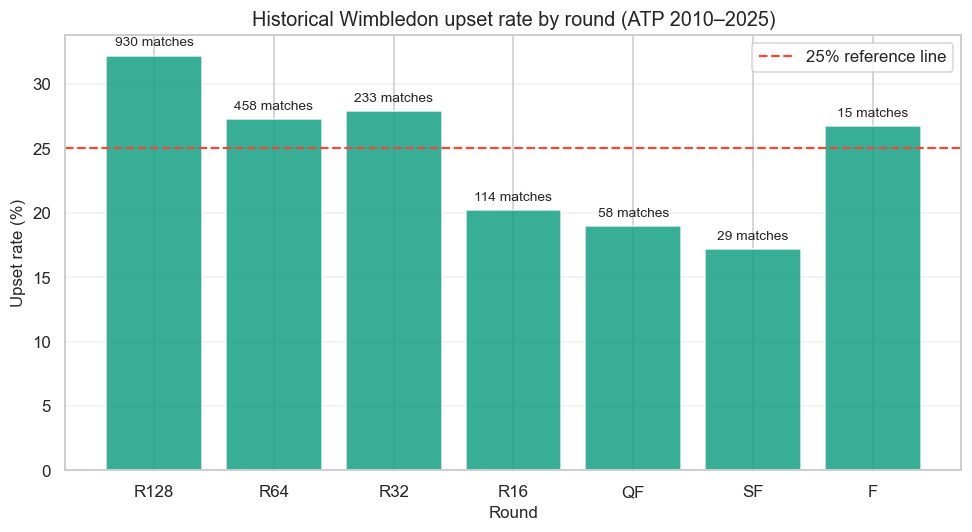

R1 upset rate: 32.2% → QF: 19.0% — upsets become rarer as weaker players are eliminated


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(main_draw['round'], main_draw['upset_rate_pct'],
              color='#16a085', alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(bars, main_draw.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{int(row['total_matches'])} matches", ha='center', va='bottom', fontsize=9)
ax.axhline(25, color='#e74c3c', linestyle='--', lw=1.5, label='25% reference line')
ax.set_xlabel('Round', fontsize=11)
ax.set_ylabel('Upset rate (%)', fontsize=11)
ax.set_title('Historical Wimbledon upset rate by round (ATP 2010–2025)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

r1 = main_draw[main_draw['round'] == 'R128']['upset_rate_pct'].values[0]
qf = main_draw[main_draw['round'] == 'QF']['upset_rate_pct'].values[0]
print(f'R1 upset rate: {r1:.1f}% → QF: {qf:.1f}% — upsets become rarer as weaker players are eliminated')

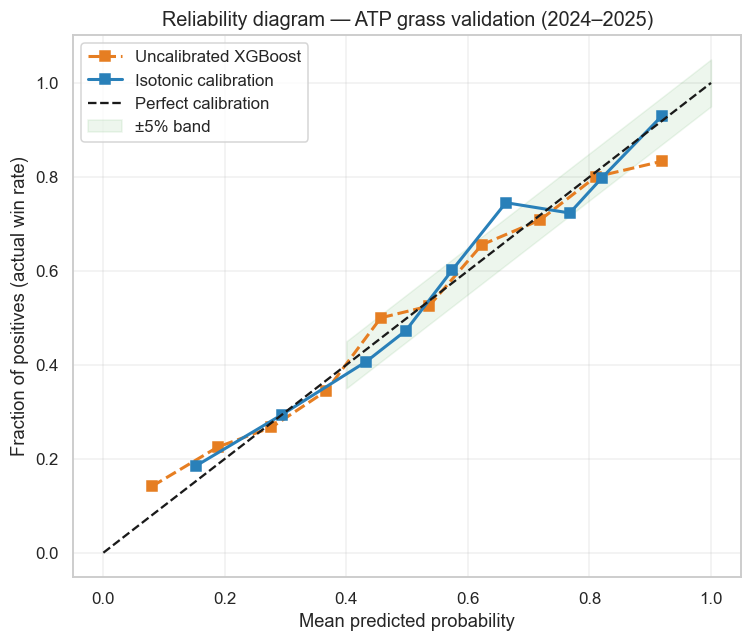

Log-loss: uncalibrated=0.5738  calibrated=0.5752
Calibration reduced log-loss by -0.15 centinats


In [12]:
# Reliability diagram: does predicted probability match actual win rate?
frac_raw, pred_raw = calibration_curve(y_g, prob_raw, n_bins=10, strategy='quantile')
frac_cal, pred_cal = calibration_curve(y_g, prob_cal, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pred_raw, frac_raw, 's--', color='#e67e22', label='Uncalibrated XGBoost', lw=2)
ax.plot(pred_cal, frac_cal, 's-',  color='#2980b9', label='Isotonic calibration', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax.fill_between([0.4, 1], [0.35, 0.95], [0.45, 1.05], alpha=0.07, color='green', label='±5% band')
ax.set_xlabel('Mean predicted probability', fontsize=12)
ax.set_ylabel('Fraction of positives (actual win rate)', fontsize=12)
ax.set_title('Reliability diagram — ATP grass validation (2024–2025)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

raw_ll = log_loss(y_g, prob_raw)
cal_ll = log_loss(y_g, prob_cal)
print(f'Log-loss: uncalibrated={raw_ll:.4f}  calibrated={cal_ll:.4f}')
print(f'Calibration reduced log-loss by {(raw_ll-cal_ll)*100:.2f} centinats')

---
## Bonus: Ad-hoc DuckDB queries

The `sql()` helper runs any DuckDB SQL against the raw CSV files.

In [13]:
surface_dist = sql("""
    SELECT surface, COUNT(*) AS matches,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM read_csv_auto('tennis_atp/atp_matches_*.csv', ignore_errors=true, union_by_name=true)
    WHERE tourney_level IN ('G','M','A','F')
      AND YEAR(STRPTIME(CAST(tourney_date AS VARCHAR), '%Y%m%d')) BETWEEN 2010 AND 2022
    GROUP BY surface
    ORDER BY matches DESC
""")
print('Surface distribution in training data (2010–2022):')
print(surface_dist.to_string(index=False))

Surface distribution in training data (2010–2022):
surface  matches  pct
   Hard    37266 56.5
   Clay    20592 31.2
  Grass     8060 12.2


In [14]:
grass_stats = sql(open('queries/02_grass_stats.sql').read())
print('Top 10 grass win rates (min 20 matches, 2010–2025):')
print(grass_stats.head(10).to_string(index=False))

Top 10 grass win rates (min 20 matches, 2010–2025):
 player_id           player_name country  matches  wins  win_pct  ace_rate  first_serve_pct  bp_saved_pct
    104925        Novak Djokovic     SRB      110  99.0     90.0    0.0991           0.6673        0.7112
    207989        Carlos Alcaraz     ESP       39  35.0     89.7    0.0896           0.6306        0.6996
    103819         Roger Federer     SUI      117 100.0     85.5    0.1184           0.6631        0.7233
    103888            Mardy Fish     USA       21  17.0     81.0    0.1885           0.5911        0.6216
    104918           Andy Murray     GBR      103  83.0     80.6    0.1073           0.6276        0.6764
    104745          Rafael Nadal     ESP       58  45.0     77.6    0.0736           0.6792        0.6746
    126610     Matteo Berrettini     ITA       57  44.0     77.2    0.1544           0.6400        0.7246
    105223 Juan Martin del Potro     ARG       42  31.0     73.8    0.1200           0.6712        0